In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn tensorflow nltk gensim wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Sentiment Analysis of Tweets using RNN, LSTM, and Word2Vec Embeddings

**Student Name:** Winendra Basukala  
**Student ID:** 2407057  
**Module:** Artificial Intelligence and Machine Learning  
**Assignment:** Text Classification with RNN  

In [2]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\winen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\winen\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\winen\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
dataset_path = "Racist Sexist/train_racisit.csv"
df = pd.read_csv(dataset_path)

In [4]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [5]:
df.isnull().any()

id       False
label    False
tweet    False
dtype: bool

In [6]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df['label'].value_counts())

(31962, 3)
Index(['id', 'label', 'tweet'], dtype='str')
id       0
label    0
tweet    0
dtype: int64
label
0    29720
1     2242
Name: count, dtype: int64


In [7]:
def text_processing_workflow(text_input, method="lemmatize"):
    """
    Clean and preprocess text for NLP tasks:
    - Lowercasing
    - Contraction expansion
    - URL, emoji, mention removal
    - Removing punctuation & non-alphanumeric chars
    - Stopword removal
    - Lemmatization or Stemming
    """

    # 1. Lowercase
    text = text_input.lower()

    # 2. Expand contractions (basic version)
    contractions = {
        "don't": "do not",
        "can't": "cannot",
        "it's": "it is",
        "i'm": "i am",
        "you're": "you are",
        "didn't": "did not",
        "isn't": "is not",
        "aren't": "are not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    # 3. Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # 4. Remove mentions
    text = re.sub(r"@\w+", "", text)

    # 5. Remove emojis
    text = re.sub(
        r"["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\u2702-\u27B0"
        u"\u24C2-\U0001F251"
        "]+",
        " ",
        text,
        flags=re.UNICODE
    )

    # 6. Remove punctuation & non-alphanumeric characters
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # 7. Tokenization
    tokens = text.split()

    # 8. Stopword removal (correct method)
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # 9. Lemmatization or Stemming
    if method == "lemmatize":
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

    elif method == "stem":
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(word) for word in tokens]

    else:
        raise ValueError("method must be 'lemmatize' or 'stem'")

    # 10. Final output
    return " ".join(tokens)

In [8]:
df['processed_tweet'] = df['tweet'].apply(lambda x: text_processing_workflow(x, method="lemmatize"))

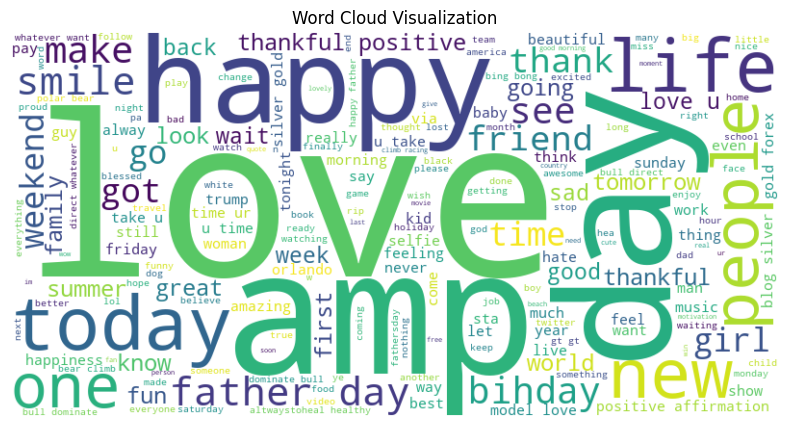

In [9]:
# Combine all cleaned tweets into a single string
combined_text = " ".join(df['processed_tweet'])
# Generate a word cloud visualization
word_cloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)
plt.figure(figsize=(10, 5))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Visualization")
plt.show()

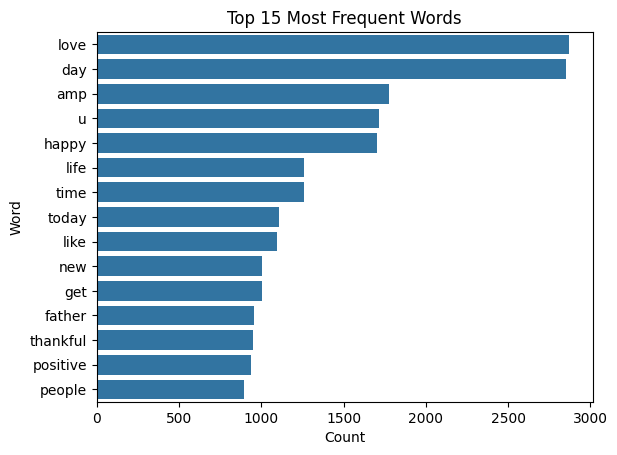

In [10]:
# Calculate word frequency
word_counts = Counter(" ".join(df["processed_tweet"]).split())
# Create a DataFrame with the top 15 most common words
top_words = pd.DataFrame(word_counts.most_common(15), columns=['Word', 'Count'])
# Plot a bar chart of the top 15 words
sns.barplot(data=top_words, x='Count', y='Word')
plt.title("Top 15 Most Frequent Words")
plt.show()

In [11]:
# Prepare features and labels for tokenization
texts = df['processed_tweet'].values
labels = df['label'].values

In [12]:
# Split data into training and validation sets
texts_train, texts_val, labels_train, labels_val = train_test_split(texts, labels, test_size=0.2, random_state=42)

In [13]:
import numpy as np
# Initialize tokenizer with out-of-vocabulary token
text_tokenizer = Tokenizer(oov_token="<OOV>")
text_tokenizer.fit_on_texts(texts_train)
total_vocab = len(text_tokenizer.word_index) + 1
print("Vocabulary size: ", total_vocab)

# Convert texts to sequences
train_sequences = text_tokenizer.texts_to_sequences(texts_train)
val_sequences = text_tokenizer.texts_to_sequences(texts_val)

# Calculate maximum sequence length based on 95th percentile
sequence_max_len = int(np.percentile([len(seq) for seq in train_sequences], 95))
print("\nMaximum Sequence Length: ", sequence_max_len)
# Pad sequences to ensure uniform length
train_padded = pad_sequences(train_sequences, maxlen=sequence_max_len, padding='post')
val_padded = pad_sequences(val_sequences, maxlen=sequence_max_len, padding='post')

Vocabulary size:  31868

Maximum Sequence Length:  14


In [23]:
def display_model_metrics(history, model_type):
    """
    Visualizes training and validation metrics for a given model.
    """
    plt.figure(figsize=(12, 6))
    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_type}: Train vs Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_type}: Train vs Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout(pad=4.0)
    plt.show()

In [15]:
def assess_model_performance(model, model_type):
    """
    Evaluates the performance of a given model on validation data.
    """
    # Calculate validation loss and accuracy
    val_loss, val_accuracy = model.evaluate(val_padded, labels_val, verbose=0)
    print('Validation Loss:', val_loss)
    print('\nValidation Accuracy:', val_accuracy)
    # Predict labels for validation data
    predicted_labels = (model.predict(val_padded) > 0.5).astype(int)
    print(f"\n\n{model_type} Accuracy: {accuracy_score(labels_val, predicted_labels):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(labels_val, predicted_labels))
    print("Classification Report:\n", classification_report(labels_val, predicted_labels))

In [16]:
# Define early stopping to prevent overfitting
stop_early = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
# Save the best model during training
rnn_saver = ModelCheckpoint('rnn_best.keras', monitor='val_loss', save_best_only=True)
lstm_saver = ModelCheckpoint('lstm_best.keras', monitor='val_loss', save_best_only=True)
glove_saver = ModelCheckpoint('glove_best.keras', monitor='val_loss', save_best_only=True)

Model 1: Simple RNN with trainable Embedding Layer

In [18]:
# Build a simple RNN model
simple_rnn = Sequential([
    Embedding(input_dim=total_vocab, output_dim=64),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])
# Compile the model
simple_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Build model with input shape
simple_rnn.build(input_shape=(None, sequence_max_len))
# Display model architecture
simple_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 14, 64)         │     2,039,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,047,873 (7.81 MB)

 Trainable params: 2,047,873 (7.81 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train the simple RNN model
simple_rnn_history = simple_rnn.fit(
    train_padded, labels_train,
    epochs=10,
    batch_size=64,
    validation_data=(val_padded, labels_val),
    callbacks=[stop_early, rnn_saver],
    verbose=1
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9409 - loss: 0.2032 - val_accuracy: 0.9559 - val_loss: 0.1329
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9824 - loss: 0.0544 - val_accuracy: 0.9565 - val_loss: 0.1358
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9965 - loss: 0.0124 - val_accuracy: 0.9459 - val_loss: 0.1871
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9983 - loss: 0.0059 - val_accuracy: 0.9420 - val_loss: 0.2165
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9982 - loss: 0.0063 - val_accuracy: 0.9451 - val_loss: 0.2245


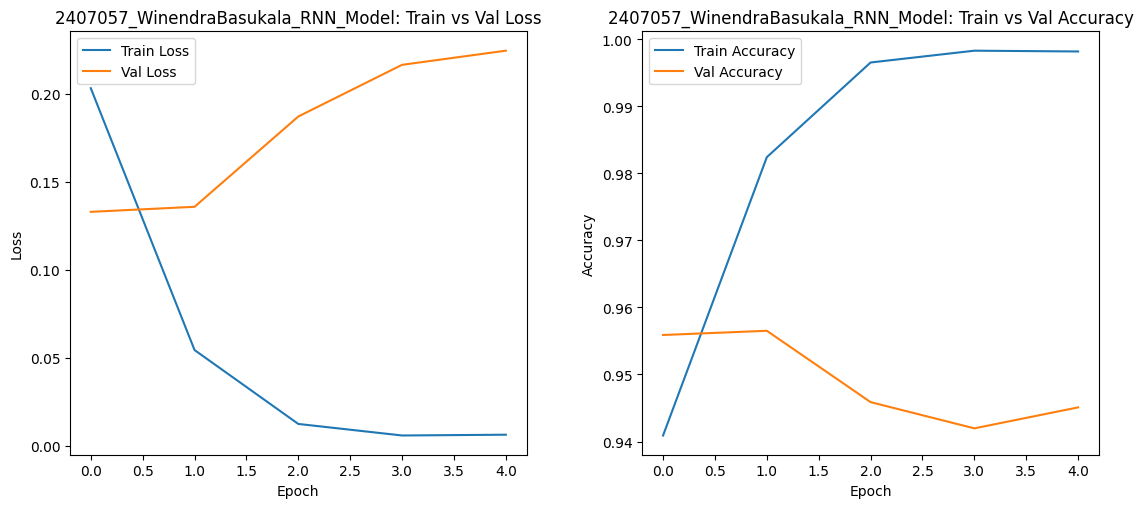

In [25]:
# Visualize training and validation metrics
display_model_metrics(simple_rnn_history, "2407057_WinendraBasukala_RNN_Model")

In [26]:
# Evaluate model performance on validation data
assess_model_performance(simple_rnn, "2407057_WinendraBasukala_RNN_Model")

Validation Loss: 0.132928729057312

Validation Accuracy: 0.9558892250061035
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


2407057_WinendraBasukala_RNN_Model Accuracy: 0.9559
Confusion Matrix:
 [[5876   61]
 [ 221  235]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      5937
           1       0.79      0.52      0.62       456

    accuracy                           0.96      6393
   macro avg       0.88      0.75      0.80      6393
weighted avg       0.95      0.96      0.95      6393



In [27]:
# Save the trained model
simple_rnn.save('2407057_WinendraBasukala_RNN_Model.keras')

Model 2: LSTM with trainable Embedding Layer

In [28]:
# Build an LSTM model with trainable embedding
lstm_model = Sequential([
    Embedding(input_dim=total_vocab, output_dim=64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

# Compile the LSTM model
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Build model with input shape
lstm_model.build(input_shape=(None, sequence_max_len))
# Display model architecture
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 14, 64)         │     2,039,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,072,641 (7.91 MB)

 Trainable params: 2,072,641 (7.91 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train the LSTM model
lstm_model_history = lstm_model.fit(
    train_padded, labels_train,
    epochs=10,
    batch_size=64,
    validation_data=(val_padded, labels_val),
    callbacks=[stop_early, lstm_saver],
    verbose=1
)


Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9485 - loss: 0.1746 - val_accuracy: 0.9607 - val_loss: 0.1165
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9794 - loss: 0.0634 - val_accuracy: 0.9620 - val_loss: 0.1262
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9907 - loss: 0.0296 - val_accuracy: 0.9609 - val_loss: 0.1677
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9953 - loss: 0.0163 - val_accuracy: 0.9582 - val_loss: 0.1528
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9970 - loss: 0.0113 - val_accuracy: 0.9485 - val_loss: 0.2254


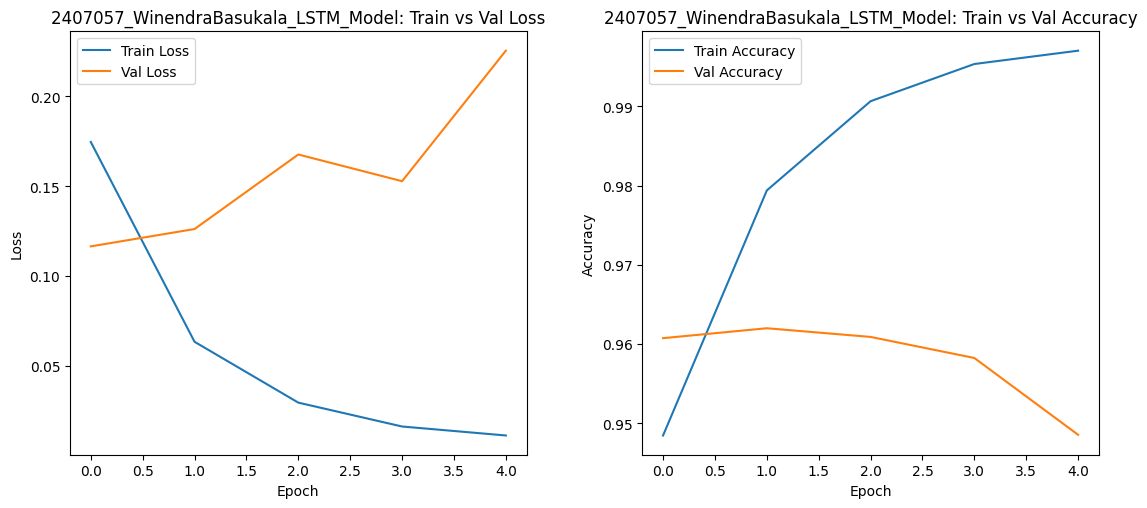

In [30]:
# Visualize training and validation metrics
display_model_metrics(lstm_model_history, "2407057_WinendraBasukala_LSTM_Model")

In [31]:
# Evaluate model performance on validation data
assess_model_performance(lstm_model, "2407057_WinendraBasukala_LSTM_Model")

Validation Loss: 0.11653558164834976

Validation Accuracy: 0.9607383012771606
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2407057_WinendraBasukala_LSTM_Model Accuracy: 0.9607
Confusion Matrix:
 [[5885   52]
 [ 199  257]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      5937
           1       0.83      0.56      0.67       456

    accuracy                           0.96      6393
   macro avg       0.90      0.78      0.83      6393
weighted avg       0.96      0.96      0.96      6393



In [32]:
# Save the trained model
lstm_model.save('2407057_WinendraBasukala_LSTM_Model.keras')

Model 3: LSTM with Pretrained GloVe Embeddings

In [33]:
import gensim.downloader as api

In [34]:
# Load pre-trained GloVe embedding model
pretrained_embeddings = api.load('glove-twitter-50')
embedding_size = 50
# Initialize embedding matrix
embedding_weights = np.zeros((total_vocab, embedding_size))
for word, index in text_tokenizer.word_index.items():
    if word in pretrained_embeddings:
        embedding_weights[index] = pretrained_embeddings[word]

[==================================================] 100.0% 199.5/199.5MB downloaded


In [35]:
# Build an LSTM model with pre-trained embeddings
lstm_model02 = Sequential([
    Embedding(input_dim=total_vocab, output_dim=embedding_size,
              weights=[embedding_weights], trainable=False),
    LSTM(64),
    Dense(1, activation='sigmoid')
])


# Compile the LSTM model
lstm_model02.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Display model architecture
lstm_model02.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     1,593,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,593,400 (6.08 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,593,400 (6.08 MB)

In [36]:
# Train the LSTM model
lstm_model02_history = lstm_model02.fit(
    train_padded, labels_train,
    epochs=10,
    batch_size=64,
    validation_data=(val_padded, labels_val),
    callbacks=[stop_early, glove_saver],
    verbose=1
)


Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9357 - loss: 0.1879 - val_accuracy: 0.9387 - val_loss: 0.1587
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9457 - loss: 0.1470 - val_accuracy: 0.9476 - val_loss: 0.1419
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9513 - loss: 0.1324 - val_accuracy: 0.9503 - val_loss: 0.1399
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9547 - loss: 0.1227 - val_accuracy: 0.9501 - val_loss: 0.1349


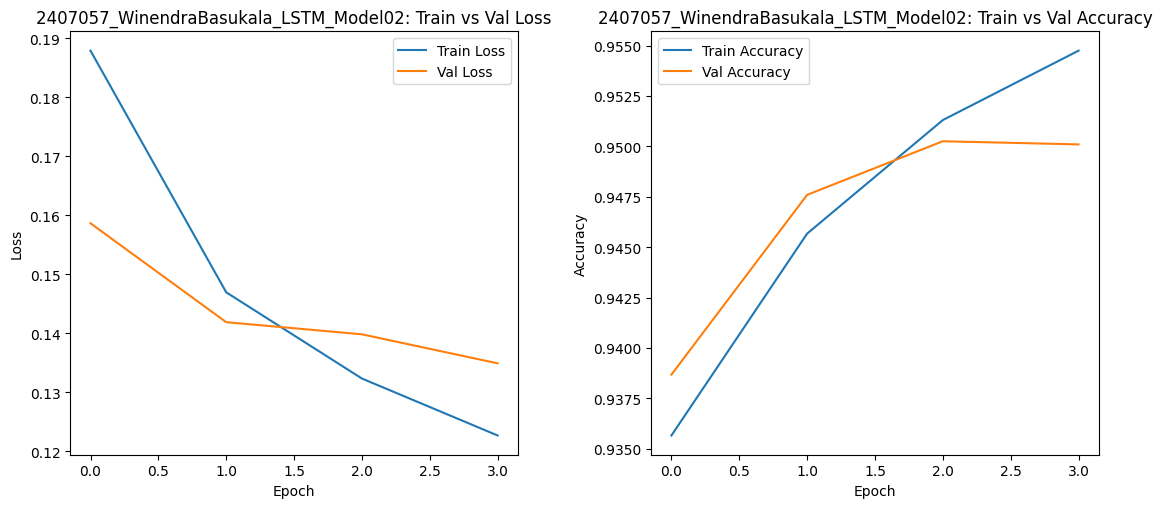

In [44]:
# Visualize training and validation metrics
display_model_metrics(lstm_model02_history, "2407057_WinendraBasukala_LSTM_Model02")

In [45]:
# Evaluate model performance on validation data
assess_model_performance(lstm_model02, "2407057_WinendraBasukala_LSTM_Model02")

Validation Loss: 0.15866349637508392

Validation Accuracy: 0.9386829137802124
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


2407057_WinendraBasukala_LSTM_Model02 Accuracy: 0.9387
Confusion Matrix:
 [[5830  107]
 [ 285  171]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97      5937
           1       0.62      0.38      0.47       456

    accuracy                           0.94      6393
   macro avg       0.78      0.68      0.72      6393
weighted avg       0.93      0.94      0.93      6393



In [46]:
# Save the trained model
lstm_model02.save('2407057_WinendraBasukala_LSTM_Model02.keras')

In [47]:
# Error analysis
preds = (lstm_model.predict(val_padded) > 0.5).astype(int)

wrong_indices = np.where(preds.flatten() != labels_val)[0]

print("Sample misclassified examples:")
for i in wrong_indices[:3]:
    print("Text:", texts_val[i])
    print("True:", labels_val[i])
    print("Pred:", preds[i][0])
    print("----")

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Sample misclassified examples:
Text: kind people need erased eah surface
True: 1
Pred: 0
----
Text: save date 1 4 2017 sourcenation live wed 8 thependulum newshow policebrutality
True: 1
Pred: 0
----
Text: already digging armorofgodstudy woman seabreeze church largo fl prayerworks activatedlife
True: 0
Pred: 1
----


Predictions

In [48]:
# Predict sentiment for custom text
def classify_text(model, model_type, text):
    """
    Predicts sentiment for a given text using the specified model.
    """
    # Clean the input text
    cleaned_text = text_processing_workflow(text)
    # Convert to sequence
    sequence = text_tokenizer.texts_to_sequences([cleaned_text])
    # Pad the sequence
    padded_sequence = pad_sequences(sequence, maxlen=sequence_max_len, padding='post')
    # Make prediction
    prediction = model.predict(padded_sequence)[0][0]
    # Determine sentiment
    sentiment_label = 'Racist/Sexist' if prediction > 0.5 else 'Not Racist/Sexist'
    print(f"\nPrediction made by model: {model_type}\n")
    print(f"Text: {text}\nPrediction: {sentiment_label} ({prediction:.3f})")

In [49]:
classify_text(
    simple_rnn,
    "2407057_WinendraBasukala_RNN_Model",
    "food time for haylie 😛 hot chocolate for mummy ☕️❜🌤🍃💯💪⚰🙓 thank god it's friday!!! 🙏🙏🙏 …"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Prediction made by model: 2407057_WinendraBasukala_RNN_Model

Text: food time for haylie 😛 hot chocolate for mummy ☕️❜🌤🍃💯💪⚰🙓 thank god it's friday!!! 🙏🙏🙏 …
Prediction: Not Racist/Sexist (0.009)


In [50]:
# LSTM Model Prediction
classify_text(lstm_model, "2407057_WinendraBasukala_LSTM_Model",
              "enjoying the sunshine! god is good. #orlando #sunshinestate #goodlife #bosslady #joy  â¦")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Prediction made by model: 2407057_WinendraBasukala_LSTM_Model

Text: enjoying the sunshine! god is good. #orlando #sunshinestate #goodlife #bosslady #joy  â¦
Prediction: Not Racist/Sexist (0.005)


In [51]:
# LSTM Model with GloVe Prediction
classify_text(lstm_model02, "2407057_WinendraBasukala_LSTM_Model02",
              "time for a pint before seeing coldplay in wembleyyyy 😳😍🎉 #coldplay #wembleystadiumâ¦")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Prediction made by model: 2407057_WinendraBasukala_LSTM_Model02

Text: time for a pint before seeing coldplay in wembleyyyy 😳😍🎉 #coldplay #wembleystadiumâ¦
Prediction: Not Racist/Sexist (0.003)


In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions
rnn_pred = (simple_rnn.predict(val_padded) > 0.5).astype(int)
lstm_pred = (lstm_model.predict(val_padded) > 0.5).astype(int)
glove_pred = (lstm_model02.predict(val_padded) > 0.5).astype(int)

# Helper function
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

# Collect results
results = pd.DataFrame([
    ["RNN", *get_metrics(labels_val, rnn_pred).values()],
    ["LSTM", *get_metrics(labels_val, lstm_pred).values()],
    ["GloVe LSTM", *get_metrics(labels_val, glove_pred).values()]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

print(results)

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
        Model  Accuracy  Precision    Recall  F1-Score
0         RNN  0.955889   0.793919  0.515351  0.625000
1        LSTM  0.960738   0.831715  0.563596  0.671895
2  GloVe LSTM  0.938683   0.615108  0.375000  0.465940


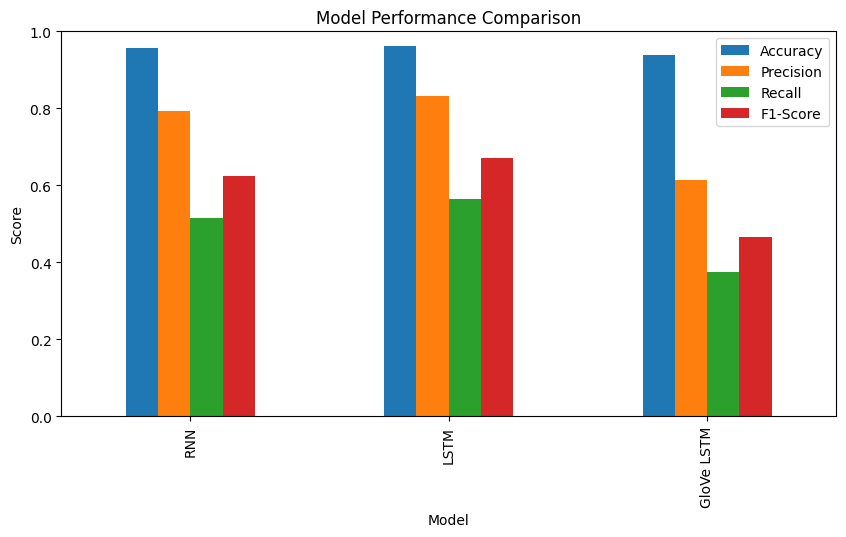

In [53]:
results.plot(x="Model", kind="bar", figsize=(10,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

In [54]:
import pickle
# Save the tokenizer for future use
with open('text_tokenizer.pickle', 'wb') as handle:
    pickle.dump(text_tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [55]:
import pickle

with open('text_tokenizer.pickle', 'rb') as handle:
    text_tokenizer = pickle.load(handle)

In [56]:
%pip install gradio
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define the models
models = {
    "Simple RNN": simple_rnn,
    "LSTM": lstm_model,
    "GloVeLSTM": lstm_model02
}

def predict_hate_speech(text, model_choice):
    try:
        if not text.strip():
            return "⚠️ Please enter some text."

        cleaned = text_processing_workflow(text)
        seq = text_tokenizer.texts_to_sequences([cleaned])
        pad = pad_sequences(seq, maxlen=sequence_max_len, padding='post')

        model = models[model_choice]
        pred = model.predict(pad, verbose=0)[0][0]

        sentiment = "🟥 Racist/Sexist" if pred > 0.5 else "🟩 Not Racist/Sexist"
        confidence = pred if pred > 0.5 else 1 - pred

        return f"Prediction: {sentiment}\nConfidence: {confidence:.2%}"

    except Exception as e:
        return f"❌ Error: {str(e)}"

gr.Interface(
    fn=predict_hate_speech,
    inputs=[
        gr.Textbox(placeholder="Enter a tweet...", lines=2),
        gr.Dropdown(choices=["Simple RNN", "LSTM", "GloVeLSTM"], label="Select Model")
    ],
    outputs="text",
    title="Tweet Classifier",
    description="Enter a tweet and select a model to detect if it's racist/sexist or not."
).launch()


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\winen\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: you may need to restart the kernel to use updated packages.
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
